In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly

In [ ]:
train=pd.read_csv('/content/train.csv',low_memory=False)
test=pd.read_csv('/content/test.csv',low_memory=False)

#Understand the Dataset

In [ ]:
print(train.shape)
print(test.shape)

(100000, 28)
(50000, 27)


In [ ]:
train.sample(10)

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
30241,0xc733,CUS_0xc106,February,Andreax,29,957-59-3053,Teacher,28081.94,2406.161667,5,...,Good,233.76,29.047424,19 Years and 9 Months,No,18.292355,125.72508790350416,High_spent_Small_value_payments,356.59872340071024,Good
40960,0x10602,CUS_0x4899,January,Jeffsr,33,175-12-3231,Mechanic,19487.77,1338.980833,6,...,Bad,2050.42,32.231479,10 Years and 2 Months,Yes,97.375555,58.50799578792363,Low_spent_Small_value_payments,268.0145320851032,Poor
21131,0x91d1,CUS_0x5e02,April,Hirschlerh,21,864-61-5672,Writer,21156.88,1643.073333,5,...,Standard,386.38,29.105186,16 Years and 5 Months,Yes,74049.000000,139.4780464333028,Low_spent_Small_value_payments,314.8292869000305,Standard
99877,0x25f37,CUS_0x3855,June,Xolai,6476,963-55-7106,Scientist,118677.54,9963.795000,4,...,Good,995.47,38.556181,30 Years and 4 Months,No,237.106366,231.2765296325449,High_spent_Large_value_payments,767.9966044929878,Good
57361,0x1661b,CUS_0x741d,February,Martinne Gellerf,35,#F%$D@*&8,Writer,21699.13,1925.260833,8,...,Standard,1129.46,37.822408,20 Years and 9 Months,Yes,45.060011,170.55882299308414,Low_spent_Large_value_payments,246.90724963637544,Standard
57876,0x1691e,CUS_0x6f0b,May,Stevenf,22,#F%$D@*&8,Lawyer,31589.06,2894.421667,8,...,Standard,1428.58,35.092451,30 Years and 7 Months,Yes,82.498344,__10000__,Low_spent_Medium_value_payments,323.4747231700062,Poor
48990,0x1350c,CUS_0xa279,July,Miedemac,37,845-19-4481,Developer,27113.76,1962.480000,7,...,Standard,834.43,31.422699,15 Years and 9 Months,Yes,97.893291,52.13974245860518,High_spent_Medium_value_payments,296.21496640954786,Standard
12485,0x5f27,CUS_0x3ade,June,Josepho,29_,085-36-7495,Writer,20000.41,1713.956327,2,...,Good,446.57,28.259403,27 Years and 7 Months,No,191.720143,52.78235445982491,Low_spent_Large_value_payments,395.7120919340965,Standard
56720,0x1625a,CUS_0x5d5f,January,Kohj,25_,740-49-8165,Teacher,60363.5,5277.291667,3,...,Good,158.8,36.440847,17 Years and 4 Months,No,0.000000,64.25978296398914,!@9#%8,703.4693837026774,Standard
46777,0x12817,CUS_0x8a1,February,Danb,33,022-55-1988,Musician,29101.2,2709.100000,8,...,Bad,1334.81,25.573954,18 Years and 8 Months,Yes,43.288984,128.5878104560584,!@9#%8,389.03320569765214,Poor


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

In [ ]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
Monthly_Inhand_Salary,84998.0,4194.170850,3183.686167,303.645417,1625.568229,3093.745000,5957.448333,15204.633333
Num_Bank_Accounts,100000.0,17.091280,117.404834,-1.000000,3.000000,6.000000,7.000000,1798.000000
Num_Credit_Card,100000.0,22.474430,129.057410,0.000000,4.000000,5.000000,7.000000,1499.000000
Interest_Rate,100000.0,72.466040,466.422621,1.000000,8.000000,13.000000,20.000000,5797.000000
Delay_from_due_date,100000.0,21.068780,14.860104,-5.000000,10.000000,18.000000,28.000000,67.000000
Num_Credit_Inquiries,98035.0,27.754251,193.177339,0.000000,3.000000,6.000000,9.000000,2597.000000
Credit_Utilization_Ratio,100000.0,32.285173,5.116875,20.000000,28.052567,32.305784,36.496663,50.000000
Total_EMI_per_month,100000.0,1403.118217,8306.041270,0.000000,30.306660,69.249473,161.224249,82331.000000


In [ ]:
train.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

#Data Preprocessing

In [ ]:
missing=train.isnull().sum()
missing=missing[missing>0]
missing.sort_index(ascending=False)

,0
Type_of_Loan,11408
Num_of_Delayed_Payment,7002
Num_Credit_Inquiries,1965
Name,9985
Monthly_Inhand_Salary,15002
Monthly_Balance,1200
Credit_History_Age,9030
Amount_invested_monthly,4479


In [ ]:
train.duplicated().sum()

np.int64(0)

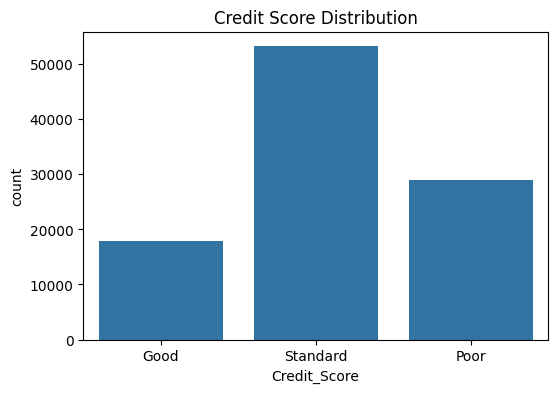

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=train,x='Credit_Score')
plt.title("Credit Score Distribution")
plt.show()

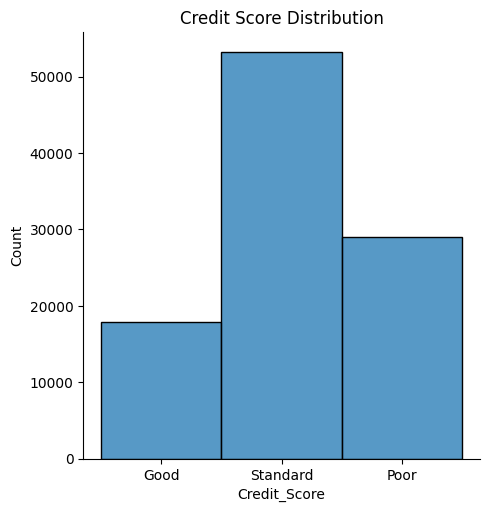

In [ ]:
sns.displot(train['Credit_Score'])
plt.title("Credit Score Distribution")
plt.show()

In [ ]:
train['Credit_Score'].value_counts()

train['Credit_Score'].value_counts(normalize=True)*100

,proportion
Credit_Score,
Standard,53.174
Poor,28.998
Good,17.828


In [ ]:
categorical_cols = [
    'Month',
    'Occupation',
    'Type_of_Loan',
    'Credit_Mix',
    'Credit_History_Age',
    'Payment_of_Min_Amount',
    'Payment_Behaviour',
    'Credit_Score'
]

In [ ]:
numeric_cols = ['Age',
    'Annual_Income',
    'Monthly_Inhand_Salary',
    'Num_Bank_Accounts',
    'Num_Credit_Card',
    'Interest_Rate',
    'Num_of_Loan',
    'Delay_from_due_date',
    'Num_of_Delayed_Payment',
    'Changed_Credit_Limit',
    'Num_Credit_Inquiries',
    'Outstanding_Debt',
    'Credit_Utilization_Ratio',
    'Total_EMI_per_month',
    'Amount_invested_monthly',
    'Monthly_Balance'
]

In [ ]:
for col in numeric_cols:
    if train[col].dtype == "object":
        print(f"\n{col}")
        print(train[col].head(10))


Age
0      23
1      23
2    -500
3      23
4      23
5      23
6      23
7      23
8     28_
9      28
Name: Age, dtype: object

Annual_Income
0    19114.12
1    19114.12
2    19114.12
3    19114.12
4    19114.12
5    19114.12
6    19114.12
7    19114.12
8    34847.84
9    34847.84
Name: Annual_Income, dtype: object

Num_of_Loan
0    4
1    4
2    4
3    4
4    4
5    4
6    4
7    4
8    1
9    1
Name: Num_of_Loan, dtype: object

Num_of_Delayed_Payment
0      7
1    NaN
2      7
3      4
4    NaN
5      4
6     8_
7      6
8      4
9      1
Name: Num_of_Delayed_Payment, dtype: object

Changed_Credit_Limit
0    11.27
1    11.27
2        _
3     6.27
4    11.27
5     9.27
6    11.27
7    11.27
8     5.42
9     7.42
Name: Changed_Credit_Limit, dtype: object

Outstanding_Debt
0    809.98
1    809.98
2    809.98
3    809.98
4    809.98
5    809.98
6    809.98
7    809.98
8    605.03
9    605.03
Name: Outstanding_Debt, dtype: object

Amount_invested_monthly
0     80.41529543900253
1    11

In [ ]:
print(train["Age"].unique()[:20])
print(train["Annual_Income"].unique()[:20])
print(train['Num_of_Loan'].unique()[:20])
print(train['Outstanding_Debt'].unique()[:20])
print(train['Amount_invested_monthly'].unique()[:20])
print(train['Monthly_Balance'].unique()[:20])

['23' '-500' '28_' '28' '34' '54' '55' '21' '31' '33' '34_' '7580' '30'
 '30_' '24' '24_' '44' '45' '40' '41']
['19114.12' '34847.84' '34847.84_' '143162.64' '30689.89' '30689.89_'
 '35547.71_' '35547.71' '73928.46' '131313.4' '10909427.0' '34081.38_'
 '34081.38' '114838.41' '114838.41_' '31370.8' '33751.27' '88640.24'
 '88640.24_' '54392.16']
['4' '1' '3' '967' '-100' '0' '0_' '2' '3_' '2_' '7' '5' '5_' '6' '8' '8_'
 '9' '9_' '4_' '7_']
['809.98' '605.03' '1303.01' '632.46' '943.86' '548.2' '352.16' '1704.18'
 '1377.74' '421.43' '1328.93' '1328.93_' '950.36' '179.22' '2602.69'
 '758.44' '818.22' '1296.64' '1283.37' '1283.37_']
['80.41529543900253' '118.28022162236736' '81.699521264648'
 '199.4580743910713' '41.420153086217326' '62.430172331195294'
 '178.3440674122349' '24.785216509052056' '104.291825168246'
 '40.39123782853101' '58.51597569589465' '99.30622796053305'
 '130.11542024292334' '43.477190144355745' '70.10177420755677'
 '218.90434353388733' '168.413702679309' '232.8603837599

In [ ]:
object_numeric = ['Age','Annual_Income','Num_of_Loan','Num_of_Delayed_Payment','Changed_Credit_Limit','Outstanding_Debt',
                  'Amount_invested_monthly','Monthly_Balance']
for col in object_numeric:
    print("="*60)
    print(col)
    print(train[col].sample(10, random_state=42).tolist())

Age
['30', '18', '41', '35', '27', '42', '34', '20', '35', '22']
Annual_Income
['43391.96', '14351.21', '130125.04', '20107.21', '92186.19', '44998.71', '56500.7', '135178.44', '75455.34_', '9155.455']
Num_of_Loan
['0', '6', '2', '2', '4', '3', '2', '0', '1', '5']
Num_of_Delayed_Payment
['6', '17', '0', '13', '0', '10', '3', '10', '13', '23']
Changed_Credit_Limit
['10.72', '21.91', '3.82', '10.4', '9.74', '16.65', '7.86', '11.27', '9.77', '27.14']
Outstanding_Debt
['1468.28', '4766.87', '1195.05', '2544.6', '809.01', '2559.56', '991.98', '1024.39', '68.09', '3914.45']
Amount_invested_monthly
['53.969385063055675', '118.08021357217683', '1255.8993022448951', '66.81977464950728', '115.52003931707223', '182.90043954253653', '621.000984980842', '969.7324794302008', '277.5692087071276', '16.968028868748124']
Monthly_Balance
['554.9302816036111', '238.3144849566528', nan, '359.23391378882377', '697.4005568630175', '411.9493600449131', '66.52676256935598', '474.5545205697992', '533.7035485614

In [ ]:
for col in train.columns:
    if train[col].astype(str).str.contains("____", regex=False).any():
        print(col)

Occupation


In [ ]:
train.replace("_______", np.nan, inplace=True)
test.replace("_______", np.nan, inplace=True)

In [ ]:
missing=train.isna().sum().sort_values(ascending=False).head(20)
missing=missing[missing>0]
print(missing)

Monthly_Inhand_Salary      15002
Type_of_Loan               11408
Name                        9985
Credit_History_Age          9030
Occupation                  7062
Num_of_Delayed_Payment      7002
Amount_invested_monthly     4479
Num_Credit_Inquiries        1965
Monthly_Balance             1200
dtype: int64


In [ ]:
for cols in object_numeric:
  train[cols]= train[cols].astype(str).str.replace('_','', regex=False)
  test[cols] = test[cols].astype(str).str.replace("_", "", regex=False)

In [ ]:
print(train["Age"].unique()[:5])
print(train["Annual_Income"].unique()[:5])
print(train['Num_of_Loan'].unique()[:5])
print(train['Outstanding_Debt'].unique()[:5])
print(train['Amount_invested_monthly'].unique()[:5])
print(train['Monthly_Balance'].unique()[:5])

['23' '-500' '28' '34' '54']
['19114.12' '34847.84' '143162.64' '30689.89' '35547.71']
['4' '1' '3' '967' '-100']
['809.98' '605.03' '1303.01' '632.46' '943.86']
['80.41529543900253' '118.28022162236736' '81.699521264648'
 '199.4580743910713' '41.420153086217326']
['312.49408867943663' '284.62916249607184' '331.2098628537912'
 '223.45130972736786' '341.48923103222177']


In [ ]:
for cols in object_numeric:
  train[cols]=pd.to_numeric(train[cols], errors='coerce')
  test[cols]=pd.to_numeric(test[cols], errors='coerce')

In [ ]:
train[object_numeric].dtypes

,0
Age,int64
Annual_Income,float64
Num_of_Loan,int64
Num_of_Delayed_Payment,float64
Changed_Credit_Limit,float64
Outstanding_Debt,float64
Amount_invested_monthly,float64
Monthly_Balance,float64


In [ ]:
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing

,0
Monthly_Inhand_Salary,15002
Type_of_Loan,11408
Name,9985
Credit_History_Age,9030
Occupation,7062
Num_of_Delayed_Payment,7002
Amount_invested_monthly,4479
Changed_Credit_Limit,2091
Num_Credit_Inquiries,1965
Monthly_Balance,1200


In [ ]:
print("Age < 18 :", (train["Age"] < 18).sum())
print("Age > 100 :", (train["Age"] > 100).sum())

print("Income < 0 :", (train["Annual_Income"] < 0).sum())

print("Loans < 0 :", (train["Num_of_Loan"] < 0).sum())
print("Loans > 20 :", (train["Num_of_Loan"] > 20).sum())

print("Outstanding Debt < 0 :", (train["Outstanding_Debt"] < 0).sum())
print('Monthly Balance < 0:', (train["Monthly_Balance"]< 0).sum())

Age < 18 : 6592
Age > 100 : 1890
Income < 0 : 0
Loans < 0 : 3876
Loans > 20 : 469
Outstanding Debt < 0 : 0
Monthly Balance < 0: 9


In [ ]:
num_cols=train.select_dtypes(include=np.number).columns
cat_cols=train.select_dtypes(include=object).columns

print('num cols:',num_cols)
print('cat cols:',cat_cols)

num cols: Index(['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio',
       'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance'],
      dtype='object')
cat cols: Index(['ID', 'Customer_ID', 'Month', 'Name', 'SSN', 'Occupation',
       'Type_of_Loan', 'Credit_Mix', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Payment_Behaviour', 'Credit_Score'],
      dtype='object')


In [ ]:
for col in cat_cols:
    print(col)
    print(train[col].nunique())
    # print("-"*40)

ID
100000
Customer_ID
12500
Month
8
Name
10139
SSN
12501
Occupation
15
Type_of_Loan
6260
Credit_Mix
4
Credit_History_Age
404
Payment_of_Min_Amount
3
Payment_Behaviour
7
Credit_Score
3


In [ ]:
train[['Age',
       'Annual_Income',
       'Num_of_Loan',
       'Outstanding_Debt',
       'Monthly_Balance']].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,100000.0,1.106497e+02,6.862447e+02,-5.000000e+02,24.000000,33.00000,42.000000,8.698000e+03
Annual_Income,100000.0,1.764157e+05,1.429618e+06,7.005930e+03,19457.500000,37578.61000,72790.920000,2.419806e+07
Num_of_Loan,100000.0,3.009960e+00,6.264788e+01,-1.000000e+02,1.000000,3.00000,5.000000,1.496000e+03
Outstanding_Debt,100000.0,1.426220e+03,1.155129e+03,2.300000e-01,566.072500,1166.15500,1945.962500,4.998070e+03
Monthly_Balance,98800.0,-3.036437e+22,3.181295e+24,-3.333333e+26,270.092209,336.71919,470.220186,1.602041e+03


In [ ]:
train.loc[(train.Age<18) | (train.Age>100),'Age']=np.nan
train.loc[(train.Annual_Income<0),'Annual_Income']=np.nan
train.loc[(train.Num_of_Loan <0) | (train.Num_of_Loan > 20),'Num_of_Loan']=np.nan
train.loc[(train.Outstanding_Debt<0),'Outstanding_Debt']=np.nan
train.loc[(train.Monthly_Balance<0),'Monthly_Balance']=np.nan

In [ ]:
test.loc[(test.Age<18) | (test.Age>100),'Age']=np.nan
test.loc[(test.Annual_Income<0),'Annual_Income']=np.nan
test.loc[(test.Num_of_Loan <0) | (test.Num_of_Loan < 20),'Num_of_Loan']=np.nan
test.loc[(test.Outstanding_Debt<0),'Outstanding_Debt']=np.nan
test.loc[(test.Monthly_Balance<0),'Monthly_Balance']=np.nan

In [ ]:
train[
    [
        "Age",
        "Annual_Income",
        "Num_of_Loan",
        "Outstanding_Debt",
        "Monthly_Balance"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,91518.0,34.429817,1.012383e+01,18.00000,26.00000,34.000000,42.000000,1.000000e+02
Annual_Income,100000.0,176415.701298,1.429618e+06,7005.93000,19457.50000,37578.610000,72790.920000,2.419806e+07
Num_of_Loan,95655.0,3.534211,2.448614e+00,0.00000,2.00000,3.000000,5.000000,1.900000e+01
Outstanding_Debt,100000.0,1426.220376,1.155129e+03,0.23000,566.07250,1166.155000,1945.962500,4.998070e+03
Monthly_Balance,98791.0,402.551258,2.139255e+02,0.00776,270.10663,336.731225,470.262938,1.602041e+03


In [ ]:
train[num_cols].dtypes

,0
Age,float64
Annual_Income,float64
Monthly_Inhand_Salary,float64
Num_Bank_Accounts,int64
Num_Credit_Card,int64
Interest_Rate,int64
Num_of_Loan,float64
Delay_from_due_date,int64
Num_of_Delayed_Payment,float64
Changed_Credit_Limit,float64


In [ ]:
train["Customer_ID"].nunique()

12500

In [ ]:
train.groupby("Customer_ID").size().value_counts()

,count
8,12500


In [ ]:
constant_cols = [
    "Age",
    "Annual_Income",
    "Monthly_Inhand_Salary"
]

for col in constant_cols:
    train[col] = train.groupby("Customer_ID")[col].transform(
        lambda x: x.ffill().bfill()
    )
    test[col]=test.groupby("Customer_ID")[col].transform(
        lambda x: x.ffill().bfill()
    )

In [ ]:
variable_cols = [
    "Num_of_Loan",
    "Outstanding_Debt",
    "Monthly_Balance",
    "Amount_invested_monthly"
]

for col in variable_cols:
    train[col] = train.groupby("Customer_ID")[col].transform(
        lambda x: x.fillna(x.median())
    )
    test[col] = test.groupby("Customer_ID")[col].transform(
        lambda x: x.fillna(x.median())
    )

In [ ]:
other_num = [
    "Num_Bank_Accounts",
    "Num_Credit_Card",
    "Interest_Rate",
    "Delay_from_due_date",
    "Num_Credit_Inquiries",
    "Credit_Utilization_Ratio",
    "Total_EMI_per_month"
]

for col in other_num:
  train[col]=train[col].fillna(train[col].median())
  test[col]=test[col].fillna(test[col].median())

In [ ]:
cat_cols = [
    "Credit_Mix",
    "Payment_of_Min_Amount",
    "Payment_Behaviour",
    "Type_of_Loan"
]

for col in cat_cols:
  mode=train[col].mode()[0]

  train[col] = train[col].fillna(mode)
  test[col]=test[col].fillna(mode)

Credit_History_Age (conversion to months)

In [ ]:
#inspect Credit_History_Age col
train["Credit_History_Age"].sample(10)

,Credit_History_Age
2051,6 Years and 2 Months
39460,23 Years and 3 Months
97235,13 Years and 0 Months
77217,1 Years and 10 Months
42318,33 Years and 4 Months
26746,17 Years and 6 Months
91716,NaN
12952,12 Years and 7 Months
73723,2 Years and 1 Months
60826,17 Years and 3 Months


In [ ]:
#creating custom function
import re

def convert_credit_history(x):
  if pd.isna(x):
    return np.nan

  match=re.match(r'(\d+)\s+Years?\s+and\s+(\d+)\s+Months?', str(x))

  if match:
    years=int(match.group(1))
    months=int(match.group(2))
    return years*12 + months

  return np.nan

In [ ]:
#Apply Function
train["Credit_History_Months"] = train["Credit_History_Age"].apply(convert_credit_history)

test["Credit_History_Months"] = test["Credit_History_Age"].apply(convert_credit_history)

In [ ]:
train[["Credit_History_Age","Credit_History_Months"]].head(15)

,Credit_History_Age,Credit_History_Months
0,22 Years and 1 Months,265.0
1,NaN,NaN
2,22 Years and 3 Months,267.0
3,22 Years and 4 Months,268.0
4,22 Years and 5 Months,269.0
5,22 Years and 6 Months,270.0
6,22 Years and 7 Months,271.0
7,NaN,NaN
8,26 Years and 7 Months,319.0
9,26 Years and 8 Months,320.0


In [ ]:
#handling constant missing value
train['Credit_History_Months']=(train.groupby('Customer_ID')['Credit_History_Months'].transform(lambda x: x.ffill().bfill()))
test['Credit_History_Months']=(test.groupby('Customer_ID')['Credit_History_Months'].transform(lambda x: x.ffill().bfill()))

In [ ]:
#handling variable missing value
median=train['Credit_History_Months'].median()
train['Credit_History_Months']=train['Credit_History_Months'].fillna(median)
test['Credit_History_Months']=test['Credit_History_Months'].fillna(median)

In [ ]:
train.drop(columns="Credit_History_Age", inplace=True)
test.drop(columns="Credit_History_Age", inplace=True)

In [ ]:
train["Credit_History_Months"].describe()

,Credit_History_Months
count,100000.000000
mean,221.136220
std,99.680454
min,1.000000
25%,144.000000
50%,219.000000
75%,302.000000
max,404.000000


#Feature Engineering

In [ ]:
train['Month'].unique()

array(['January', 'February', 'March', 'April', 'May', 'June', 'July',
       'August'], dtype=object)

In [ ]:
monthmap={
    'January':1,
    'February':2,
    'March':3,
    'April':4,
    'May':5,
    'June':6,
    'July':7,
    'August':8 }

train['Month']=train['Month'].map(monthmap)
test['Month']=test['Month'].map(monthmap)

In [ ]:
train['Debt_to_Income']=(train['Outstanding_Debt']/train['Annual_Income'])
test['Debt_to_Income']=(test['Outstanding_Debt']/test['Annual_Income'])

In [ ]:
train.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Payment_of_Min_Amount',
       'Total_EMI_per_month', 'Amount_invested_monthly', 'Payment_Behaviour',
       'Monthly_Balance', 'Credit_Score', 'Credit_History_Months',
       'Debt_to_Income'],
      dtype='object')

In [ ]:
train['EMI_ratio']=(train['Total_EMI_per_month']/train['Monthly_Inhand_Salary'])
test['EMI_ratio']=(test['Total_EMI_per_month']/test['Monthly_Inhand_Salary'])

In [ ]:
train["Investment_Ratio"] = (train["Amount_invested_monthly"] /             train['Monthly_Inhand_Salary'])
test["Investment_Ratio"] = (test["Amount_invested_monthly"] /
    test["Monthly_Inhand_Salary"]
)

In [ ]:
train['Savings']=(train['Monthly_Inhand_Salary']-train['Amount_invested_monthly'] - train['Total_EMI_per_month'])
test['Savings']=(test['Monthly_Inhand_Salary']-test['Amount_invested_monthly']-test['Total_EMI_per_month'])

In [ ]:
train["High_Utilization"] = (
    train["Credit_Utilization_Ratio"] > 50
).astype(int)

test["High_Utilization"] = (
    test["Credit_Utilization_Ratio"] > 50
).astype(int)

In [ ]:
train["Delayed_Payment"] = (
    train["Num_of_Delayed_Payment"] > 3
).astype(int)

test["Delayed_Payment"] = (
    test["Num_of_Delayed_Payment"] > 3
).astype(int)

In [ ]:
train["High_Inquiry"] = (
    train["Num_Credit_Inquiries"] > 5
).astype(int)

test["High_Inquiry"] = (
    test["Num_Credit_Inquiries"] > 5
).astype(int)

In [ ]:
train.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Monthly_Balance,Credit_Score,Credit_History_Months,Debt_to_Income,EMI_ratio,Investment_Ratio,Savings,High_Utilization,Delayed_Payment,High_Inquiry
0,0x1602,CUS_0xd40,1,Aaron Maashoh,23.0,821-00-0265,Scientist,19114.12,1824.843333,3,...,312.494089,Good,265.0,0.042376,0.027167,0.044067,1694.853089,0,1,0
1,0x1603,CUS_0xd40,2,Aaron Maashoh,23.0,821-00-0265,Scientist,19114.12,1824.843333,3,...,284.629162,Good,265.0,0.042376,0.027167,0.064817,1656.988162,0,0,0
2,0x1604,CUS_0xd40,3,Aaron Maashoh,23.0,821-00-0265,Scientist,19114.12,1824.843333,3,...,331.209863,Good,267.0,0.042376,0.027167,0.044771,1693.568863,0,1,0
3,0x1605,CUS_0xd40,4,Aaron Maashoh,23.0,821-00-0265,Scientist,19114.12,1824.843333,3,...,223.451310,Good,268.0,0.042376,0.027167,0.109301,1575.810310,0,1,0
4,0x1606,CUS_0xd40,5,Aaron Maashoh,23.0,821-00-0265,Scientist,19114.12,1824.843333,3,...,341.489231,Good,269.0,0.042376,0.027167,0.022698,1733.848231,0,0,0


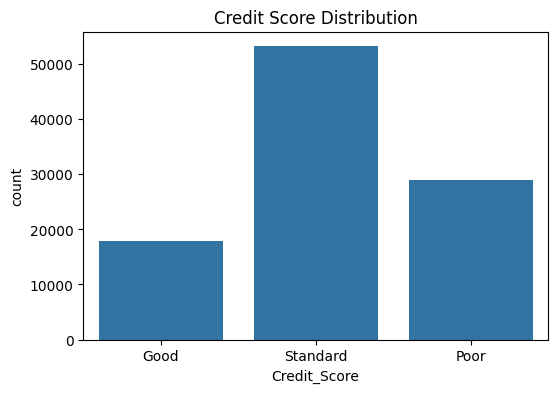

Credit_Score
Standard    53.174
Poor        28.998
Good        17.828
Name: proportion, dtype: float64


In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(data=train, x='Credit_Score')

plt.title("Credit Score Distribution")
plt.show()

print(train["Credit_Score"].value_counts(normalize=True)*100)

#Observation
* Dataset is moderately imbalanced.
* Standard Credit Score is the majority class.


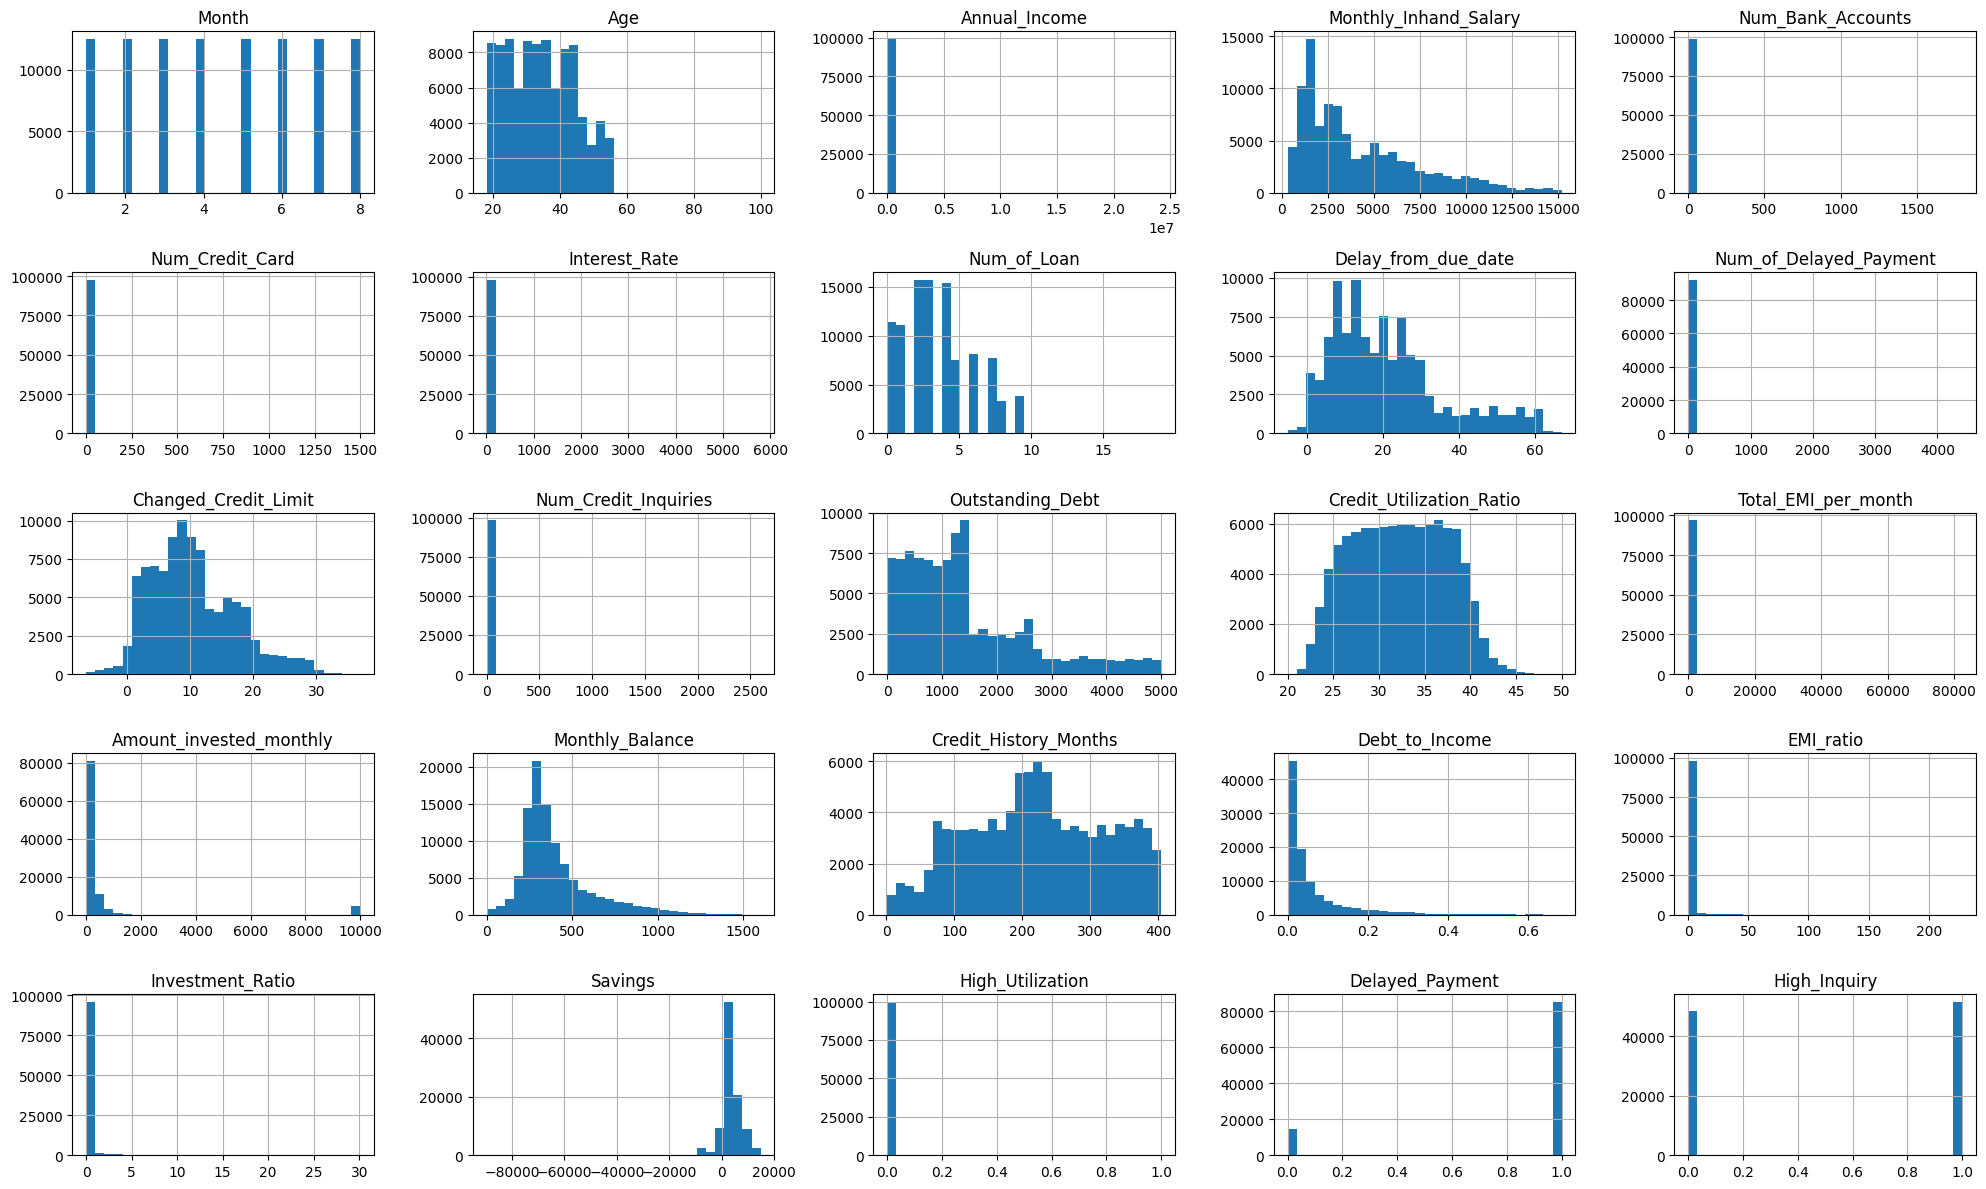

In [ ]:
num_cols = train.select_dtypes(include=np.number).columns

train[num_cols].hist(figsize=(20,12), bins=30)

plt.tight_layout()

plt.show()

#Observation
Most financial variables such as Annual_Income, Monthly_Inhand_Salary, Outstanding_Debt, Monthly_Balance, and Debt_to_Income are positively skewed, indicating that most customers have relatively lower values while a small number have very high values. Credit_Utilization_Ratio appears approximately symmetric, whereas Credit_History_Months is well distributed across its range. Binary engineered features (High_Utilization, Delayed_Payment, High_Inquiry) show the expected 0/1 distributions. Some variables contain long right tails, suggesting the presence of high-value customers or potential outliers.

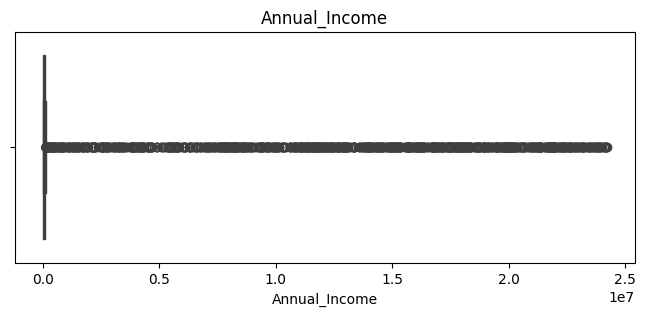

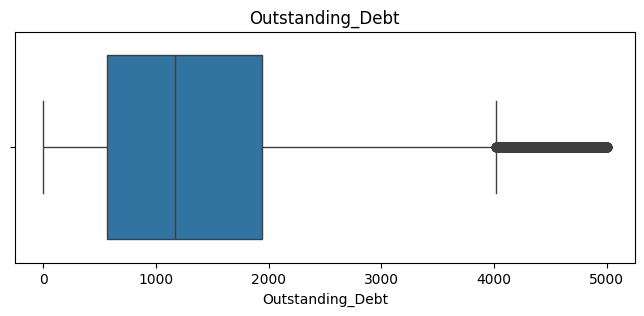

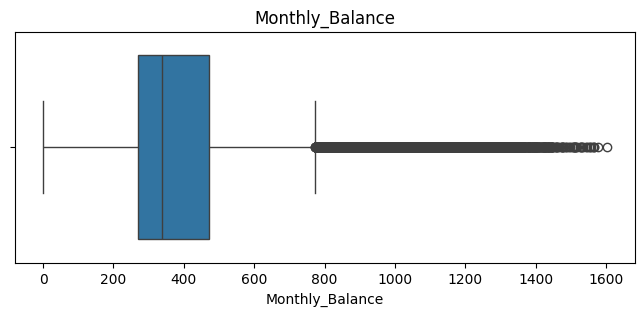

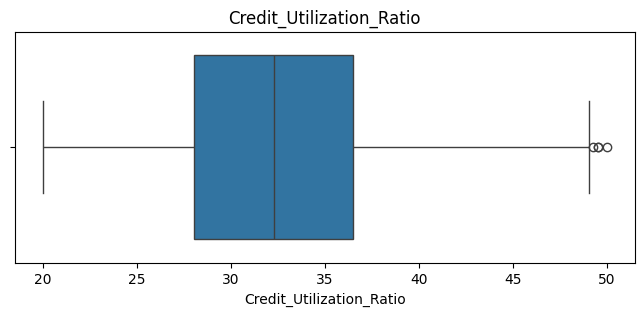

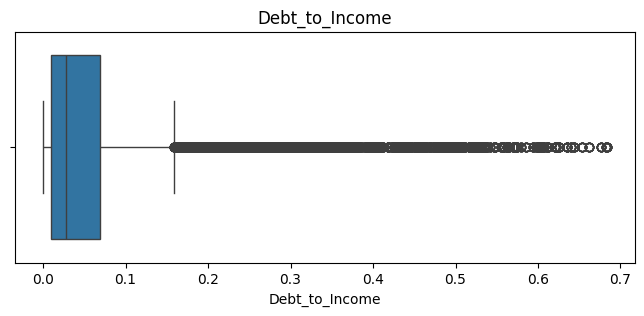

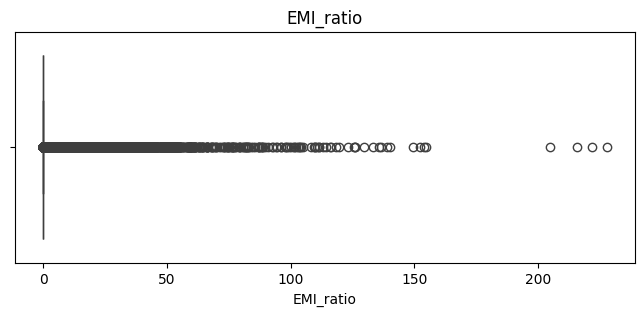

In [ ]:
important = ["Annual_Income","Outstanding_Debt","Monthly_Balance",   "Credit_Utilization_Ratio","Debt_to_Income","EMI_ratio"]
for col in important:
    plt.figure(figsize=(8,3))
    sns.boxplot(x=train[col])
    plt.title(col)
    plt.show()

#Observation
Boxplot Analysis: Most financial features contain statistical outliers, particularly Annual_Income, Monthly_Balance, Debt_to_Income, and EMI_Ratio. These outliers are primarily due to naturally skewed financial distributions rather than data entry errors. Credit_Utilization_Ratio exhibits comparatively fewer outliers and a more balanced spread. Since the project aims to predict real-world credit scores and tree-based models are robust to extreme values, these outliers will be retained.

Removing invalid income values

In [ ]:
print(train["Annual_Income"].describe(percentiles=[0.90, 0.95, 0.99, 0.999]))
print(train["Annual_Income"].nlargest(10))

count    1.000000e+05
mean     1.764157e+05
std      1.429618e+06
min      7.005930e+03
50%      3.757861e+04
90%      1.130859e+05
95%      1.345333e+05
99%      1.799873e+05
99.9%    2.175213e+07
max      2.419806e+07
Name: Annual_Income, dtype: float64
48302    24198062.0
7814     24188807.0
59059    24177153.0
14588    24160009.0
27262    24105369.0
39829    24105151.0
12307    24096975.0
85379    24065688.0
61389    24008957.0
81585    23942655.0
Name: Annual_Income, dtype: float64


In [ ]:
print(train.loc[
    train["Annual_Income"] > 2_000_000,
    ["Annual_Income","Monthly_Inhand_Salary"]
].head(20))

print((train["Annual_Income"] > 2_000_000).sum())

      Annual_Income  Monthly_Inhand_Salary
54       10909427.0           10469.207759
231       6515990.0            2210.032500
361      18334118.0            4369.482500
368      19717385.0            1057.435833
379       2709655.0            7489.973333
420       2592822.0            1012.480000
564      19257912.0           11809.560000
602      22335783.0            3580.457500
617      16367214.0           10795.632500
862       8908998.0            1904.950417
895       9351702.0            1851.335000
918       2547968.0            2430.718333
1253     15560525.0            1273.740417
1464      4282515.0            1304.910833
1546     16174808.0            8205.496667
1706     21246612.0            2431.045000
1737     14089102.0            1403.237500
2099     12311582.0            1371.406667
2303     22409880.0            2342.356667
2533      5444147.0            1698.773333
924


In [ ]:
(train["Annual_Income"] /
(train["Monthly_Inhand_Salary"]*12)
).describe()

,0
count,100000.000000
mean,5.599311
std,69.581852
min,0.674152
25%,0.962842
50%,1.002150
75%,1.046121
max,4509.210176


In [ ]:
train["Annual_Income"].quantile([0.95,0.99,0.995,0.999])

,Annual_Income
0.950,1.345333e+05
0.990,1.799873e+05
0.995,1.292096e+07
0.999,2.175213e+07


In [ ]:
# Calculate ratio
ratio = train["Annual_Income"] / (train["Monthly_Inhand_Salary"] * 12)

# Remove only unrealistically HIGH values
train.loc[ratio > 5, "Annual_Income"] = np.nan

# Fill missing values within each customer
train["Annual_Income"] = (
    train.groupby("Customer_ID")["Annual_Income"]
         .transform(lambda x: x.fillna(x.median()))
)

# Fill any remaining missing values with global median
train["Annual_Income"] = train["Annual_Income"].fillna(
    train["Annual_Income"].median()
)

# Verify
print("Income > 2M:", (train["Annual_Income"] > 2_000_000).sum())

ratio = train["Annual_Income"] / (train["Monthly_Inhand_Salary"] * 12)
print(ratio.describe())

Income > 2M: 0
count    100000.000000
mean          1.011436
std           0.107962
min           0.674152
25%           0.962430
50%           1.001406
75%           1.043899
max           4.913423
dtype: float64


In [ ]:
print((train["Annual_Income"] > 2_000_000).sum())

0


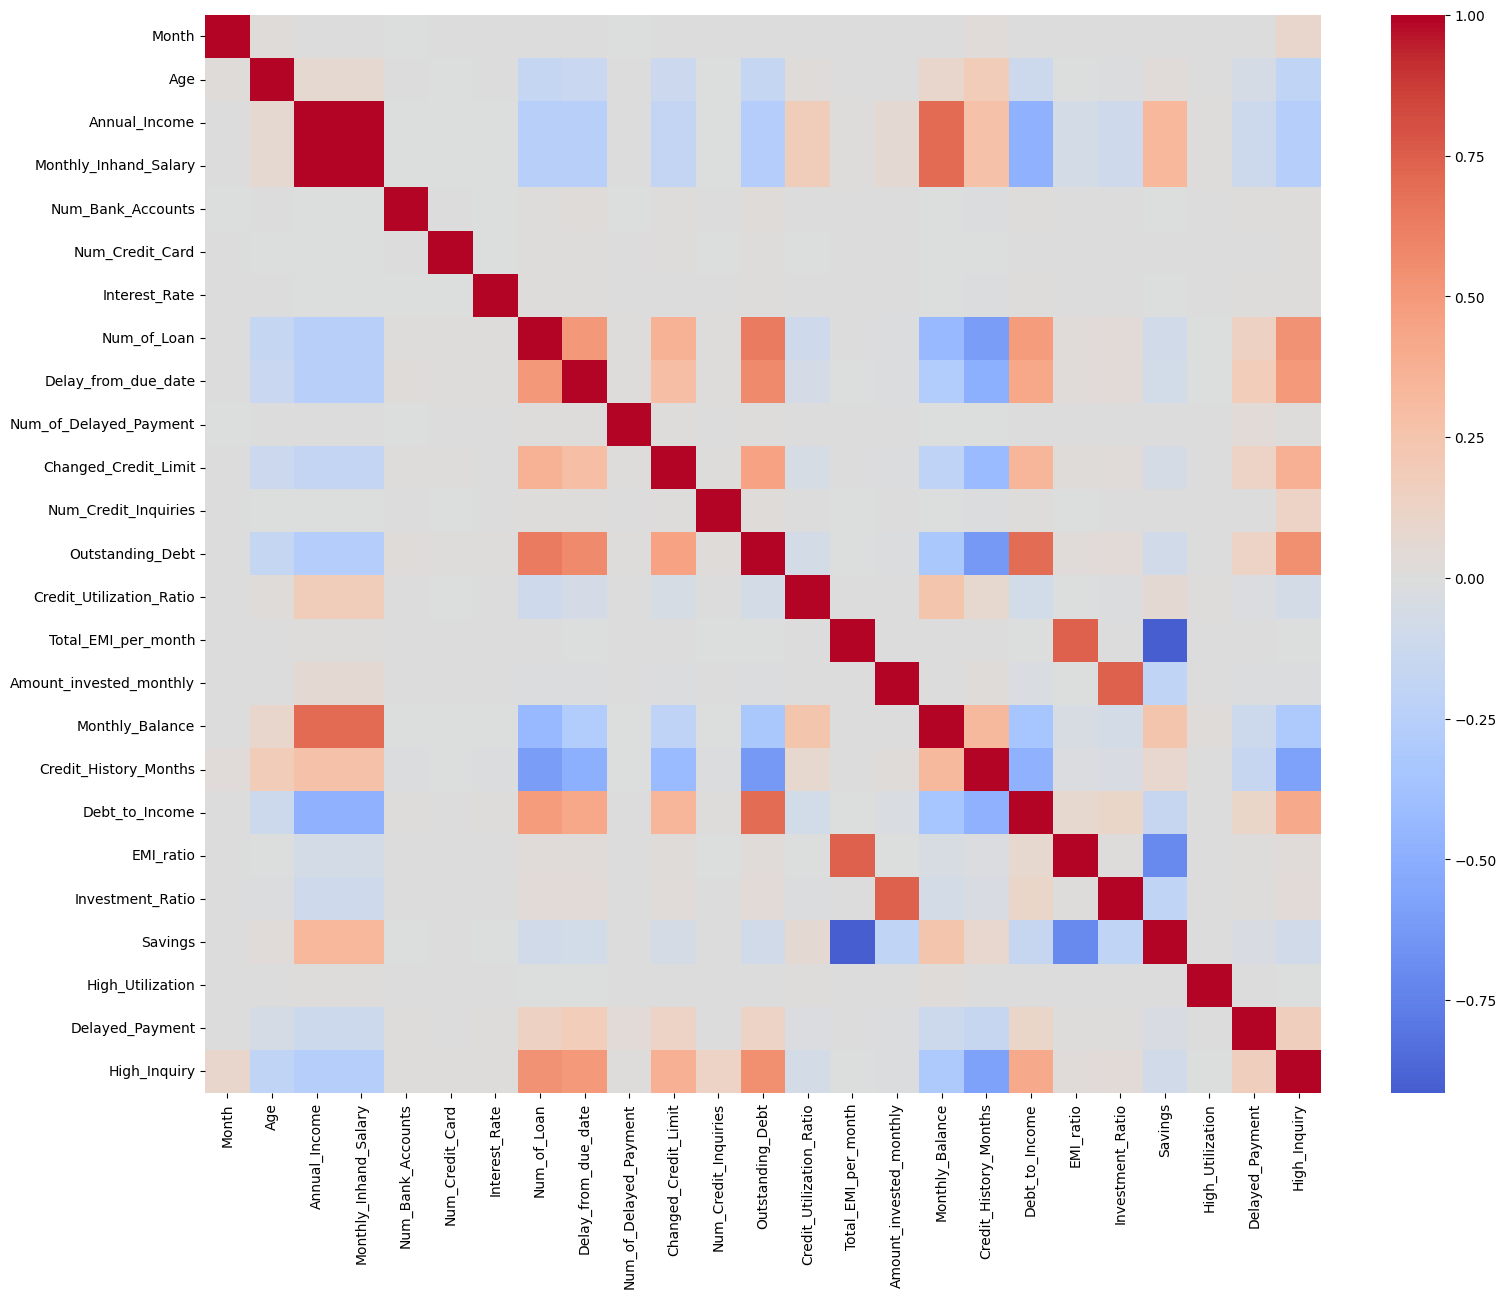

In [ ]:
plt.figure(figsize=(18,14))

corr = train.select_dtypes(include=np.number).corr()

sns.heatmap(corr,
            cmap="coolwarm",
            center=0)

plt.show()

#Observation
 Key Positive Correlations
- **Annual_Income ↔ Monthly_Inhand_Salary** shows a very strong positive correlation, which is expected because monthly salary is derived from annual income.
- **Outstanding_Debt ↔ Debt_to_Income** has a strong positive correlation, indicating that customers with higher debt generally have a higher debt burden relative to their income.
- **Total_EMI_per_month ↔ EMI_ratio** shows a very high positive correlation since EMI ratio is calculated using monthly EMI.
- **Amount_invested_monthly ↔ Investment_Ratio** is strongly positively correlated because the ratio is derived from investment amount.
- **Monthly_Balance ↔ Savings** shows a moderate positive correlation, suggesting customers maintaining higher balances generally have more savings.

 Key Negative Correlations
- **Credit_History_Months ↔ Outstanding_Debt** shows a negative relationship, indicating customers with longer credit histories generally carry lower debt.
- **Credit_History_Months ↔ Debt_to_Income** is also negatively correlated, suggesting financially experienced customers manage debt more efficiently.
- **Monthly_Balance ↔ Outstanding_Debt** has a negative correlation, meaning customers with higher debt usually maintain lower account balances.

<Axes: xlabel='Credit_Score', ylabel='Annual_Income'>

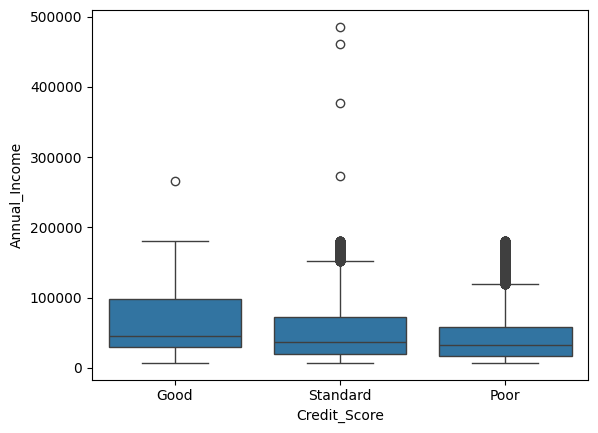

In [ ]:
sns.boxplot(data=train, x="Credit_Score", y="Annual_Income")

#Observation
- Annual income varies across all credit score categories.
- Customers with **Good** credit scores generally have a slightly higher median income.
- Although several income outliers exist, most customers earn below ₹2 lakh annually after data cleaning.
- Income alone does not strongly determine credit score.

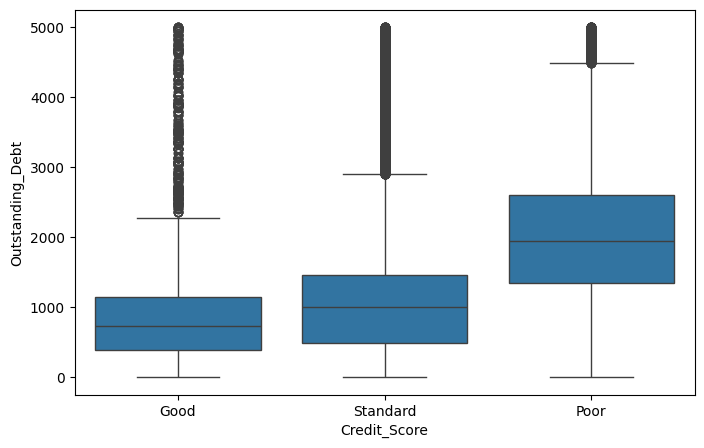

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(data=train,x="Credit_Score",y="Outstanding_Debt")

plt.show()

#Observation
- Customers with **Poor** credit scores have the highest median outstanding debt.
- Good credit customers generally maintain the lowest debt levels.
- Numerous high-value debt outliers indicate some customers carry exceptionally large debts.

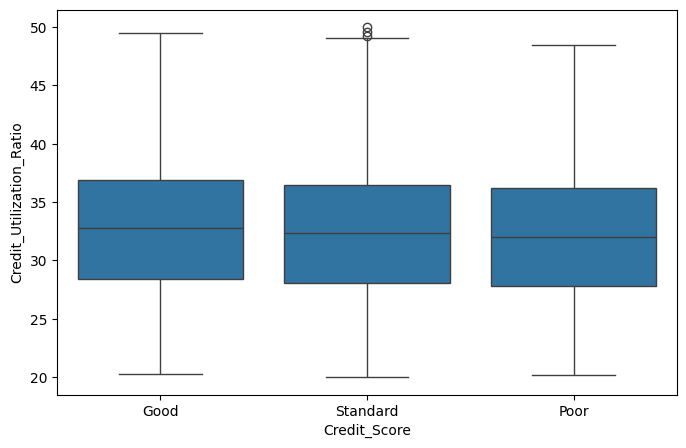

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=train,x="Credit_Score",y="Credit_Utilization_Ratio")
plt.show()

#Observation
- Credit utilization distributions are fairly similar across all credit score groups.
- Median utilization remains around 30–33%.
- This suggests utilization alone is insufficient to distinguish credit score categories.

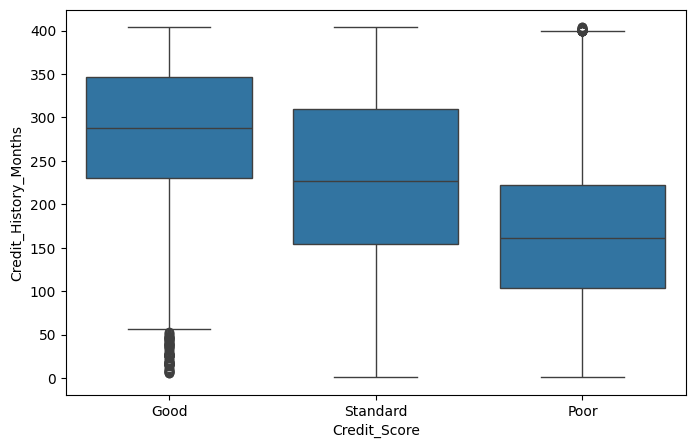

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=train,x="Credit_Score",y="Credit_History_Months")
plt.show()

#Observation
- Customers with **Good** credit scores generally possess the longest credit history.
- Poor credit customers have noticeably shorter credit histories.
- Longer credit history appears associated with better creditworthiness.

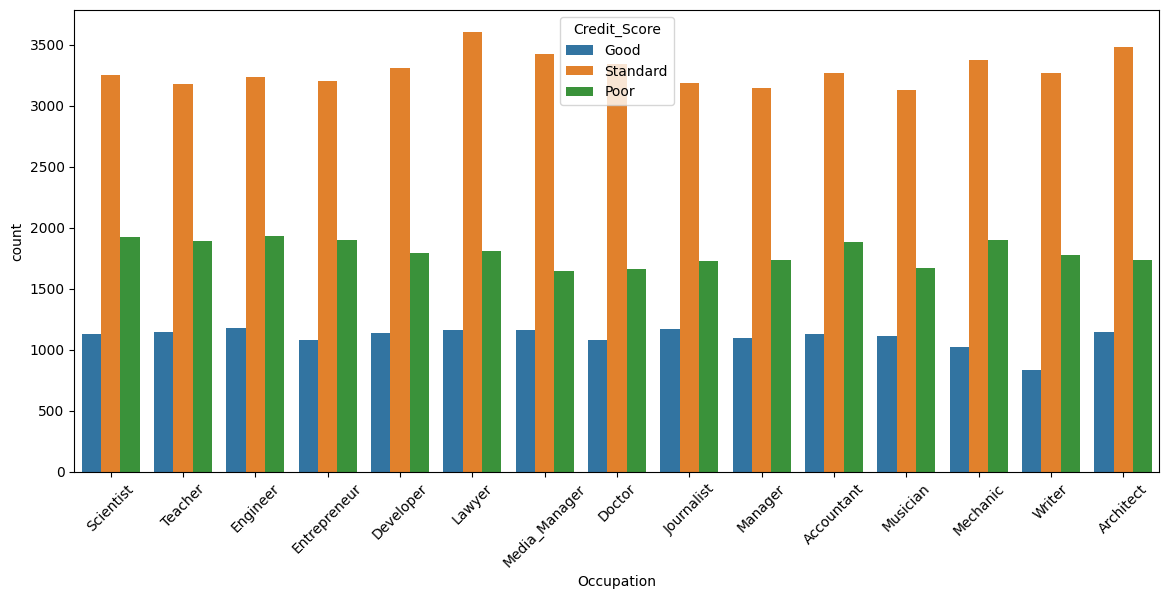

In [ ]:
plt.figure(figsize=(14,6))
sns.countplot(data=train,x="Occupation",hue="Credit_Score")
plt.xticks(rotation=45)
plt.show()

#Observation
## Occupation-wise Credit Score Distribution
- Standard credit score is the most common category across every occupation.
- Good and Poor credit scores are distributed across all occupations without major differences.
- No occupation appears to dominate any particular credit score category.
- Occupation alone is unlikely to be a strong predictor of credit score.

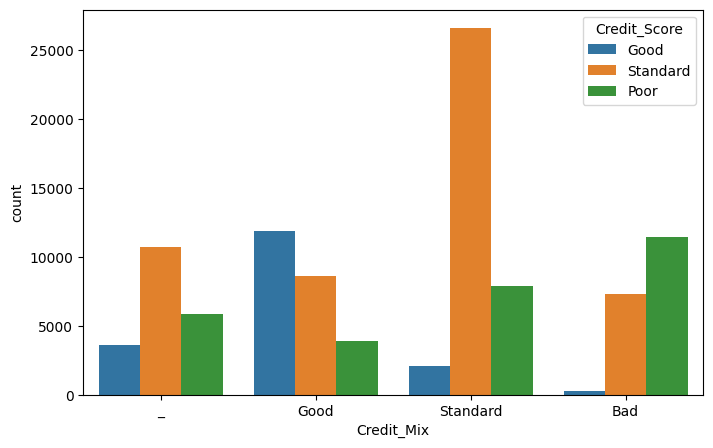

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=train,
    x="Credit_Mix",
    hue="Credit_Score"
)

plt.show()

## Credit Mix Analysis

- Customers with a **Good Credit Mix** mostly belong to the Good credit score category.
- Customers with a **Bad Credit Mix** are largely concentrated in the Poor credit score category.
- Standard Credit Mix contains the highest number of Standard credit score customers.
- Credit Mix appears to be one of the strongest predictors of customer credit score.

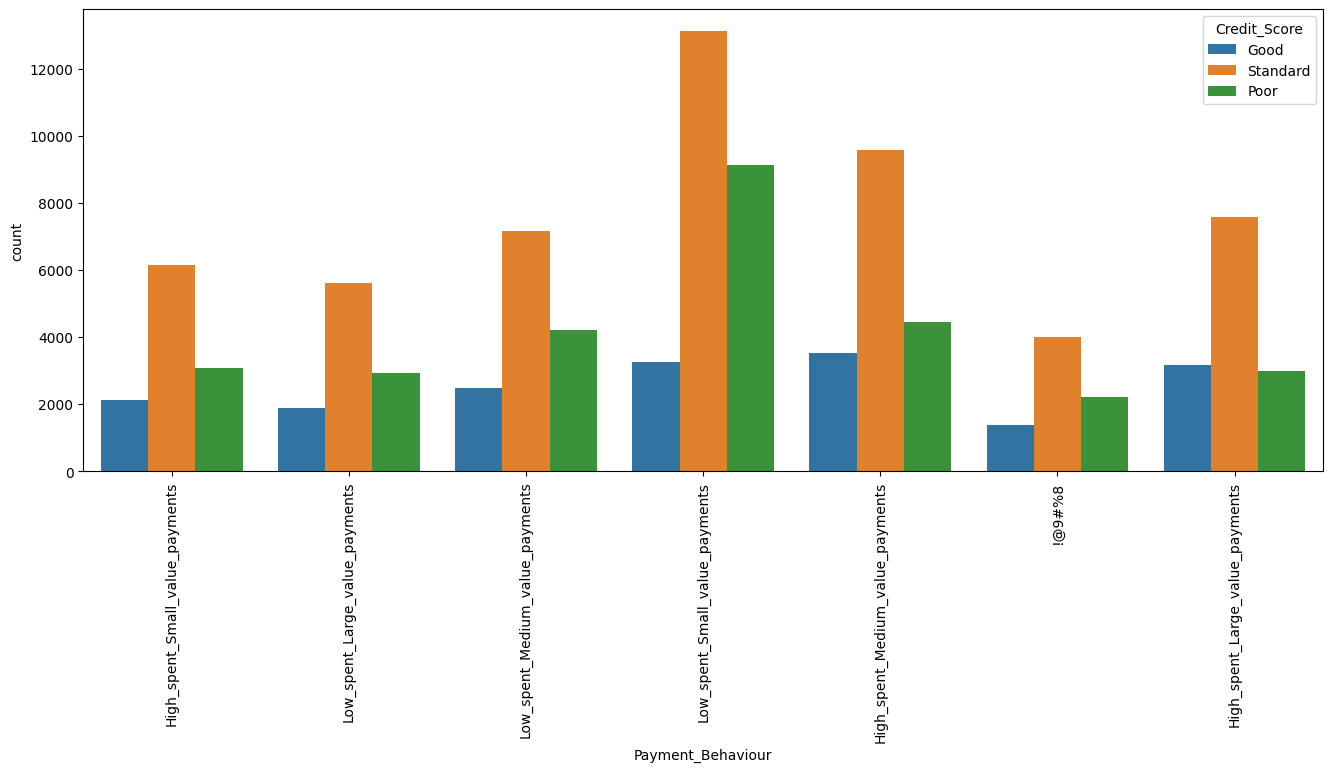

In [ ]:
plt.figure(figsize=(16,6))
sns.countplot(
    data=train,
    x="Payment_Behaviour",
    hue="Credit_Score"
)
plt.xticks(rotation=90)
plt.show()

## Payment Behaviour Analysis

- Customers with Low Spent–Small Value Payments are predominantly classified as Standard credit score.
- High Spent–Medium Value Payments show comparatively more Good credit score customers.
- Poor credit score customers are concentrated in payment behaviours involving frequent low-value payments.
- Payment behaviour demonstrates a noticeable association with customer creditworthiness.

### Overall EDA Conclusion
The exploratory analysis suggests that financial behaviour variables such as Outstanding Debt, Credit History, Debt-to-Income Ratio, Credit Mix and Payment Behaviour have a much stronger relationship with Credit Score than demographic variables like Age or Occupation. Therefore, the machine learning model is expected to rely primarily on customers' financial behaviour rather than personal characteristics.

In [ ]:
train.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Payment_of_Min_Amount',
       'Total_EMI_per_month', 'Amount_invested_monthly', 'Payment_Behaviour',
       'Monthly_Balance', 'Credit_Score', 'Credit_History_Months',
       'Debt_to_Income', 'EMI_ratio', 'Investment_Ratio', 'Savings',
       'High_Utilization', 'Delayed_Payment', 'High_Inquiry'],
      dtype='object')

#DataPreprocessing After EDA

In [ ]:
train["Interest_Rate"].describe()

train["Interest_Rate"].nlargest(30)
for col in train.select_dtypes(include="number"):
    print(col)
    print(train[col].describe(percentiles=[0.99]))
    print(train[col].nlargest(5))
    print("-"*40)
import pandas as pd

for col in train.select_dtypes(include="number").columns:

    print("="*80)
    print(f"{col}")

    print("\nDescribe:")
    print(train[col].describe(percentiles=[0.95,0.99,0.995,0.999]))

    print("\nLargest Values:")
    print(train[col].nlargest(10).values)

    print("\nSmallest Values:")
    print(train[col].nsmallest(10).values)

    print("\nMissing Values:", train[col].isna().sum())
train.loc[
    (train["Interest_Rate"] < 1) |
    (train["Interest_Rate"] > 40),
    "Interest_Rate"
] = np.nan

train["Interest_Rate"] = (
    train.groupby("Customer_ID")["Interest_Rate"]
    .transform(lambda x: x.fillna(x.median()))
)

train["Interest_Rate"] = train["Interest_Rate"].fillna(
    train["Interest_Rate"].median()
)
train.loc[
    (train["Num_Bank_Accounts"] < 1) |
    (train["Num_Bank_Accounts"] > 15),
    "Num_Bank_Accounts"
] = np.nan
train.loc[
    (train["Num_Credit_Card"] > 15),
    "Num_Credit_Card"
] = np.nan
train.loc[
    train["Num_Credit_Inquiries"] > 20,
    "Num_Credit_Inquiries"
] = np.nan
train.loc[
    (train["Num_of_Delayed_Payment"] < 0) |
    (train["Num_of_Delayed_Payment"] > 60),
    "Num_of_Delayed_Payment"
] = np.nan
train.loc[
    train["Delay_from_due_date"] < 0,
    "Delay_from_due_date"
] = np.nan
train["Total_EMI_per_month"].nlargest(20)
cols = [
    "Interest_Rate",
    "Num_Bank_Accounts",
    "Num_Credit_Card",
    "Num_Credit_Inquiries",
    "Num_of_Delayed_Payment",
    "Delay_from_due_date"
]

for col in cols:
    train[col] = (
        train.groupby("Customer_ID")[col]
        .transform(lambda x: x.fillna(x.median()))
    )

    train[col] = train[col].fillna(train[col].median())
train["EMI_ratio"] = train["EMI_ratio"].clip(upper=5)
train["Investment_Ratio"] = train["Investment_Ratio"].clip(upper=5)
emi_income_ratio = (
    train["Total_EMI_per_month"] /
    train["Monthly_Inhand_Salary"]
)

emi_income_ratio.describe([0.95,0.99,0.999])
train.loc[
    emi_income_ratio > 5,
    [
        "Customer_ID",
        "Annual_Income",
        "Monthly_Inhand_Salary",
        "Total_EMI_per_month"
    ]
].head(20)
train.loc[
    emi_income_ratio > 5,
    "Total_EMI_per_month"
] = np.nan

train["Total_EMI_per_month"] = (
    train.groupby("Customer_ID")["Total_EMI_per_month"]
         .transform(lambda x: x.fillna(x.median()))
)

train["Total_EMI_per_month"] = (
    train["Total_EMI_per_month"]
         .fillna(train["Total_EMI_per_month"].median())
)

Month
count    100000.000000
mean          4.500000
std           2.291299
min           1.000000
50%           4.500000
99%           8.000000
max           8.000000
Name: Month, dtype: float64
7     8
15    8
23    8
31    8
39    8
Name: Month, dtype: int64
----------------------------------------
Age
count    94496.000000
mean        34.354957
std         10.151178
min         18.000000
50%         34.000000
99%         55.000000
max        100.000000
Name: Age, dtype: float64
29316    100.0
28718     99.0
38248     95.0
65420     95.0
78564     95.0
Name: Age, dtype: float64
----------------------------------------
Annual_Income
count    100000.000000
mean      50519.082042
std       38371.180979
min        7005.930000
50%       36999.705000
99%      166907.720000
max      485755.000000
Name: Annual_Income, dtype: float64
44215    485755.0
76193    461219.0
22739    377503.0
45977    273093.0
98852    265962.0
Name: Annual_Income, dtype: float64
-----------------------------------

#Model Train

(100000, 34)
(100000,)
['Good' 'Poor' 'Standard']
(80000, 34)
(20000, 34)
0.81605
              precision    recall  f1-score   support

           0       0.78      0.77      0.78      3566
           1       0.80      0.83      0.82      5799
           2       0.84      0.82      0.83     10635

    accuracy                           0.82     20000
   macro avg       0.81      0.81      0.81     20000
weighted avg       0.82      0.82      0.82     20000

[[2738   13  815]
 [  60 4824  915]
 [ 692 1184 8759]]


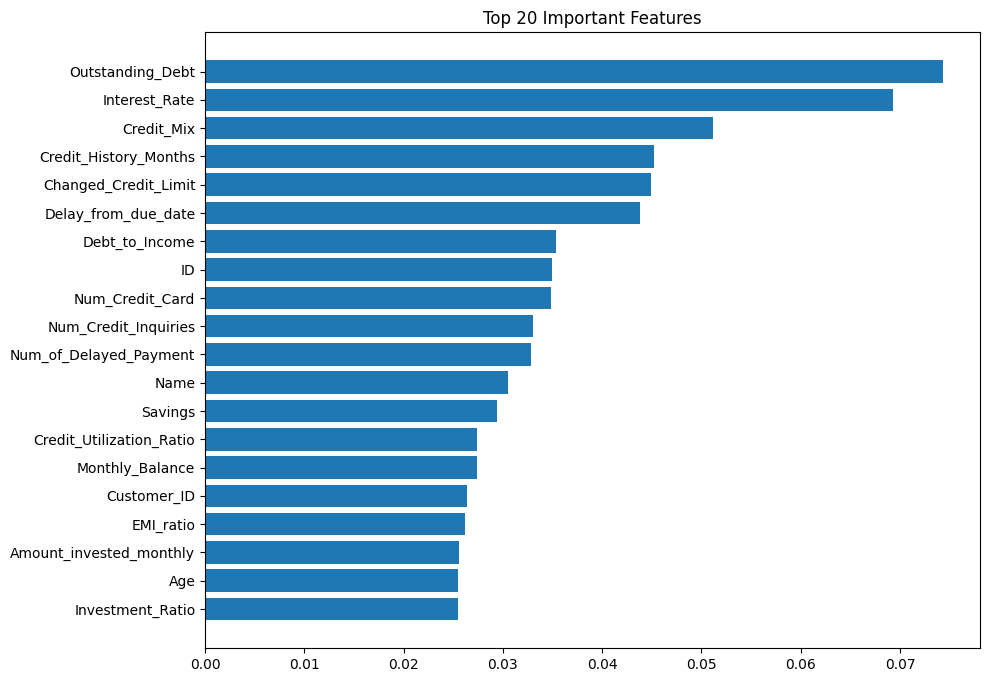

['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Payment_of_Min_Amount', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance', 'Credit_History_Months', 'Debt_to_Income', 'EMI_ratio', 'Investment_Ratio', 'Savings', 'High_Utilization', 'Delayed_Payment', 'High_Inquiry']


In [ ]:
X = train.drop("Credit_Score", axis=1)
y = train["Credit_Score"]
print(X.shape)
print(y.shape)
cat_cols = X.select_dtypes(include="object").columns

cat_cols
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

X[cat_cols] = encoder.fit_transform(X[cat_cols])
X.shape
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
y=le.fit_transform(y)
print(le.classes_)
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print(X_train.shape)
print(X_test.shape)
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42,n_estimators=100)

rf.fit(X_train, y_train)
y_pred=rf.predict(X_test)
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, y_pred))
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)
import matplotlib.pyplot as plt
top20 = importance.head(20)
plt.figure(figsize=(10,8))
plt.barh(top20["Feature"], top20["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 Important Features")
plt.show()
print(X.columns.tolist())

#hyper

Fitting 3 folds for each of 1 candidates, totalling 3 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best Parameters:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None, 'class_weight': None, 'bootstrap': True}

Best CV Accuracy:
0.7975499894678527
Test Accuracy: 0.8196
              precision    recall  f1-score   support

        Good       0.79      0.77      0.78      3566
        Poor       0.80      0.83      0.82      5799
    Standard       0.84      0.83      0.83     10635

    accuracy                           0.82     20000
   macro avg       0.81      0.81      0.81     20000
weighted avg       0.82      0.82      0.82     20000



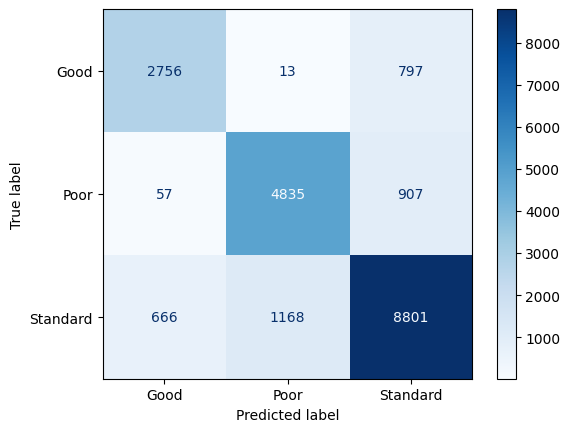

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestClassifier(random_state=42)

# param_dist = {
#     "n_estimators": [200],
#     "max_depth": [15, 20, 30, None],
#     "min_samples_split": [2,5],
#     "min_samples_leaf": [1, 2],
#     "max_features": ["sqrt", "log2"],
#     "bootstrap": [True],
#     "class_weight": [None, "balanced"]
# }

param_dist = {
    "n_estimators": [200],
    "max_depth": [None],
    "min_samples_split": [2],
    "min_samples_leaf": [1],
    "max_features": ["log2"],
    "bootstrap": [True],
    "class_weight": [None]
}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=10,              # Increase to 30 if time permits
    scoring="accuracy",
    cv=3,                   # 3-fold is enough
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV Accuracy:")
print(random_search.best_score_)
best_rf = random_search.best_estimator_

y_pred = best_rf.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

print("Test Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(
    y_test,
    y_pred,
    target_names=le.classes_
))
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    best_rf,
    X_test,
    y_test,
    display_labels=le.classes_,
    cmap="Blues"
)
plt.show()

In [ ]:
wrong = X_test.copy()
wrong["Actual"] = le.inverse_transform(y_test)
wrong["Predicted"] = le.inverse_transform(y_pred)

wrong = wrong[wrong["Actual"] != wrong["Predicted"]]

wrong

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_History_Months,Debt_to_Income,EMI_ratio,Investment_Ratio,Savings,High_Utilization,Delayed_Payment,High_Inquiry,Actual,Predicted
31428,91492.0,12479.0,5,8837.0,27.0,1934.0,1.0,39255.540,3546.295000,4.0,...,401.0,0.013655,0.012981,0.056381,3300.317233,0,0,1,Standard,Good
74979,36211.0,5310.0,4,1268.0,46.0,6127.0,9.0,146101.280,12012.106667,3.0,...,209.0,0.008976,0.025570,0.033055,11307.904541,0,1,1,Poor,Standard
25685,85749.0,5590.0,6,1159.0,35.0,7082.0,14.0,106077.600,8744.800000,3.0,...,247.0,0.002842,0.036856,0.016597,8277.361288,0,1,0,Standard,Poor
7415,67479.0,2256.0,8,2218.0,31.0,5092.0,NaN,148990.160,12474.846667,3.0,...,354.0,0.002736,0.021432,0.093472,11041.434219,0,1,0,Good,Standard
82733,44448.0,1830.0,6,5854.0,30.0,1757.0,9.0,143570.800,12000.233333,1.0,...,388.0,0.009274,0.010276,0.036978,11433.182924,0,0,0,Poor,Standard
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94307,56747.0,7634.0,4,5015.0,NaN,1313.0,4.0,47330.910,3793.242500,9.0,...,154.0,0.030755,0.027201,0.033151,3564.314082,0,1,1,Standard,Poor
95777,58307.0,442.0,2,8989.0,23.0,69.0,9.0,42527.040,3374.920000,8.0,...,126.0,0.098614,0.068229,0.016587,3088.670023,0,1,1,Standard,Poor
63225,23721.0,9785.0,2,1635.0,34.0,6842.0,9.0,21765.990,1942.832500,3.0,...,382.0,0.039800,0.008517,0.022494,1882.584039,0,1,0,Poor,Good
17413,77477.0,8106.0,6,8691.0,35.0,2367.0,11.0,30472.500,2270.375000,3.0,...,171.0,0.061438,0.056724,0.015341,2106.759212,0,1,1,Standard,Poor


Advance FE

In [ ]:
# Number of loan types mentioned
train["Loan_Count"] = (
      train["Type_of_Loan"]
         .fillna("")
         .apply(lambda x: len(str(x).split(",")) if x != "" else 0)
)

loan_types = [
    "Auto Loan",
    "Home Equity Loan",
    "Mortgage Loan",
    "Student Loan",
    "Personal Loan",
    "Payday Loan",
    "Credit-Builder Loan",
    "Debt Consolidation Loan",
    "Not Specified"
]

for loan in loan_types:
    col = loan.replace(" ", "_").replace("-", "_")
    train[f"Has_{col}"] = (
        train["Type_of_Loan"]
             .fillna("")
             .str.contains(loan, case=False)
             .astype(int)
    )

In [ ]:
train["Payment_Behaviour"] = train["Payment_Behaviour"].fillna("Unknown")

train["Spending_Level"] = (
    train["Payment_Behaviour"]
         .str.extract(r'(Low|High)')
)

train["Payment_Size"] = (
    train["Payment_Behaviour"]
         .str.extract(r'(Small|Medium|Large)')
)

In [ ]:
customer_stats = train.groupby("Customer_ID").agg({

    "Outstanding_Debt":"mean",
    "Delay_from_due_date":"mean",
    "Credit_Utilization_Ratio":"mean",
    "Savings":"mean",
    "EMI_ratio":"mean",
    "Monthly_Balance":"mean"

}).add_prefix("CustAvg_")

train = train.merge(
    customer_stats,
    on="Customer_ID",
    how="left"
)

In [ ]:
import numpy as np

train["Month_sin"] = np.sin(
    2*np.pi*train["Month"]/12
)

train["Month_cos"] = np.cos(
    2*np.pi*train["Month"]/12
)

In [ ]:
train["Credit_Health_Index"] = (
    train["Credit_History_Months"]/(train["Outstanding_Debt"]+1)
)

In [ ]:
train["Loan_Burden"] = (
    train["Num_of_Loan"] *
    train["EMI_ratio"]
)

In [ ]:
train["Delinquency_Score"] = (
      train["Delay_from_due_date"]
    + train["Num_of_Delayed_Payment"]
    + train["Num_Credit_Inquiries"]
)

In [ ]:
drop_cols = [
    "ID",
    "Customer_ID",
    "Name",
    "SSN",
    "Credit_Score",
    "Type_of_Loan",
    "Payment_Behaviour"
]

X = train.drop(columns=drop_cols)
y = train["Credit_Score"]

In [ ]:
cat_cols = X.select_dtypes(include="object").columns

encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

X[cat_cols] = encoder.fit_transform(X[cat_cols])

In [ ]:
le = LabelEncoder()
y = le.fit_transform(y)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
best_rf.fit(X_train, y_train)

RandomForestClassifier(max_features='log2', n_estimators=200, random_state=42)

In [ ]:
y_pred=best_rf.predict(X_test)
from sklearn.metrics import accuracy_score
print("accuracy:",accuracy_score(y_test, y_pred))
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

accuracy: 0.825
              precision    recall  f1-score   support

           0       0.80      0.77      0.79      3566
           1       0.81      0.84      0.83      5799
           2       0.84      0.83      0.84     10635

    accuracy                           0.82     20000
   macro avg       0.82      0.82      0.82     20000
weighted avg       0.83      0.82      0.82     20000



In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[2757    1  808]
 [  40 4876  883]
 [ 648 1120 8867]]


#Advanced Feature Engineering - Phase 2 (Customer Behavior Features)

In [ ]:
customer_features = train.groupby("Customer_ID").agg({

    "Outstanding_Debt": ["mean", "max"],
    "Delay_from_due_date": ["mean", "max"],
    "Credit_Utilization_Ratio": ["mean"],
    "Monthly_Balance": ["mean"],
    "Savings": ["mean"],
    "EMI_ratio": ["mean"],
    "Debt_to_Income": ["mean"]

})

customer_features.columns = [
    "_".join(col) for col in customer_features.columns
]

customer_features = customer_features.reset_index()

train = train.merge(
    customer_features,
    on="Customer_ID",
    how="left"
)

In [ ]:
stability = train.groupby("Customer_ID").agg({

    "Monthly_Balance":"std",
    "Monthly_Inhand_Salary":"std"

})

stability.columns = [
    "Balance_Stability",
    "Income_Stability"
]

stability = stability.reset_index()

train = train.merge(
    stability,
    on="Customer_ID",
    how="left"
)

train["Balance_Stability"] = train["Balance_Stability"].fillna(0)
train["Income_Stability"] = train["Income_Stability"].fillna(0)

In [ ]:
train["Credit_History_Years"] = (
    train["Credit_History_Months"] / 12
)

In [ ]:
train["Debt_per_Loan"] = (
    train["Outstanding_Debt"] /
    (train["Num_of_Loan"] + 1)
)

In [ ]:
train["Savings_Rate"] = (
    train["Savings"] /
    (train["Monthly_Inhand_Salary"] + 1)
)

In [ ]:
train["Investment_Capacity"] = (
    train["Amount_invested_monthly"] /
    (train["Monthly_Inhand_Salary"] + 1)
)

In [ ]:
train["High_Risk"] = (
    (train["Credit_Utilization_Ratio"] > 70) &
    (train["Delay_from_due_date"] > 30)
).astype(int)

In [ ]:
drop_cols = [
    "ID",
    "Name",
    "SSN",
    "Credit_Score",
    "Type_of_Loan",
    "Payment_Behaviour"
]

X = train.drop(columns=drop_cols)
y = train["Credit_Score"]

In [ ]:
cat_cols = X.select_dtypes(include="object").columns

encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

X[cat_cols] = encoder.fit_transform(X[cat_cols])

#Model Training Random Forest

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd

# Encode target
le = LabelEncoder()
y = le.fit_transform(y)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)



In [ ]:
print(X.shape)
print(X.isnull().sum().sort_values(ascending=False).head(20))

(100000, 68)
Spending_Level              7600
Payment_Size                7600
Occupation                  7062
Age                         5504
Changed_Credit_Limit        2091
Month                          0
Customer_ID                    0
Annual_Income                  0
Interest_Rate                  0
Num_of_Loan                    0
Num_Bank_Accounts              0
Monthly_Inhand_Salary          0
Num_of_Delayed_Payment         0
Num_Credit_Inquiries           0
Credit_Mix                     0
Outstanding_Debt               0
Credit_Utilization_Ratio       0
Payment_of_Min_Amount          0
Delay_from_due_date            0
Num_Credit_Card                0
dtype: int64


In [ ]:
X = X.fillna(X.median(numeric_only=True))

In [ ]:
best_rf.fit(X_train, y_train)

# Prediction
y_pred = best_rf.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(
    y_test,
    y_pred,
    target_names=['Good', 'Poor', 'Standard']
))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Feature Importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 20 Features")
display(importance.head(20))

Accuracy: 0.83045

              precision    recall  f1-score   support

        Good       0.81      0.79      0.80      3566
        Poor       0.81      0.85      0.83      5799
    Standard       0.85      0.83      0.84     10635

    accuracy                           0.83     20000
   macro avg       0.82      0.82      0.82     20000
weighted avg       0.83      0.83      0.83     20000

[[2814    1  751]
 [  10 4939  850]
 [ 632 1147 8856]]

Top 20 Features


,Feature,Importance
14,Credit_Mix,0.042647
8,Interest_Rate,0.040523
49,Credit_Health_Index,0.034869
53,Outstanding_Debt_max,0.034371
52,Outstanding_Debt_mean,0.032471
41,CustAvg_Outstanding_Debt,0.031670
51,Delinquency_Score,0.030116
15,Outstanding_Debt,0.029336
12,Changed_Credit_Limit,0.027960
54,Delay_from_due_date_mean,0.025034


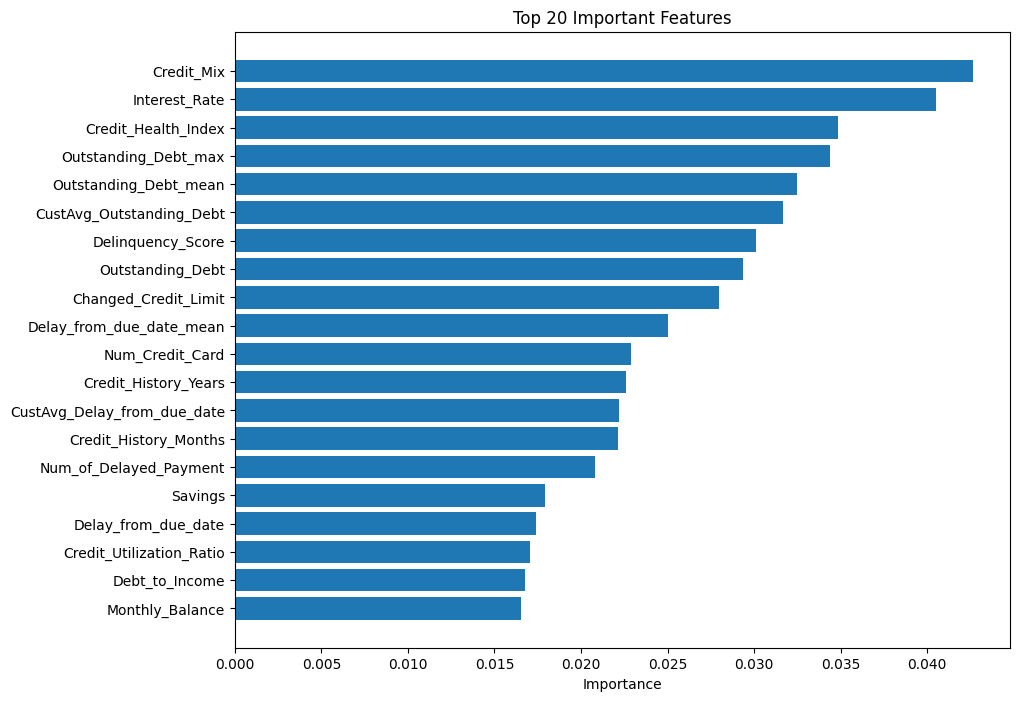

In [ ]:
import matplotlib.pyplot as plt

top20 = importance.head(20)

plt.figure(figsize=(10,8))
plt.barh(top20["Feature"], top20["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 Important Features")
plt.xlabel("Importance")
plt.show()

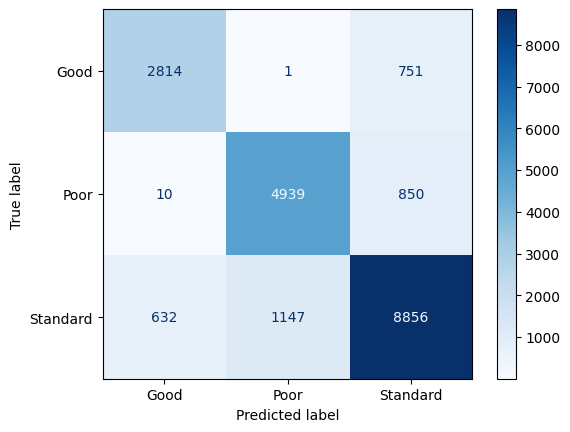

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    best_rf,
    X_test,
    y_test,
    display_labels=le.classes_,
    cmap="Blues"
)

plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize
# Predict probabilities
y_prob = best_rf.predict_proba(X_test)
# One-vs-Rest labels
y_test_bin = label_binarize(y_test, classes=[0,1,2])
auc = roc_auc_score(
    y_test_bin,
    y_prob,
    multi_class="ovr"
)

print("Multiclass ROC-AUC:", round(auc,4))

Multiclass ROC-AUC: 0.9383


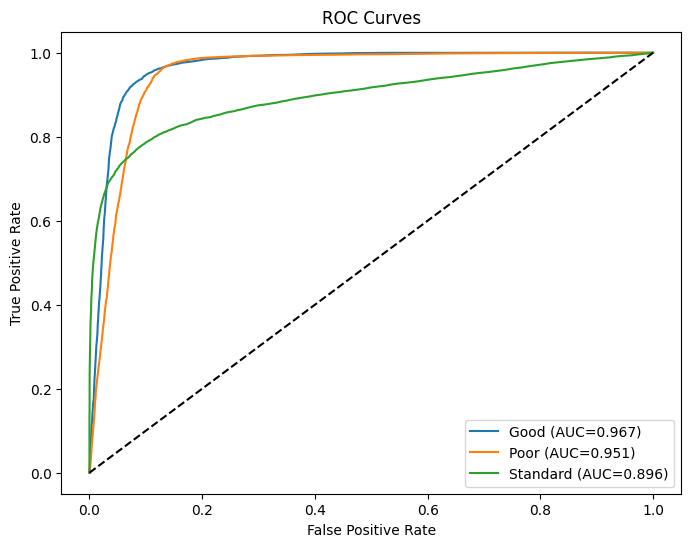

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

classes = le.classes_

plt.figure(figsize=(8,6))

for i in range(len(classes)):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:,i],
        y_prob[:,i]
    )

    roc_auc = auc(fpr,tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{classes[i]} (AUC={roc_auc:.3f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")

plt.legend()

plt.show()

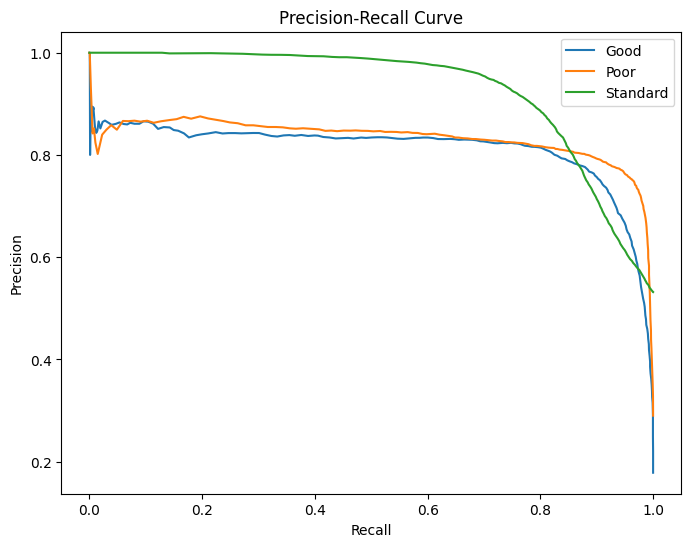

In [ ]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(8,6))

for i in range(len(classes)):

    precision, recall, _ = precision_recall_curve(
        y_test_bin[:,i],
        y_prob[:,i]
    )

    plt.plot(
        recall,
        precision,
        label=classes[i]
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.legend()

plt.show()

#Try Catboost model

In [ ]:
!pip install -q catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.0 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

In [ ]:
cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=8,
    loss_function="MultiClass",
    eval_metric="Accuracy",
    random_seed=42,
    verbose=100
)

In [ ]:
cat_model.fit(X_train,y_train)

0:	learn: 0.6746125	total: 672ms	remaining: 5m 35s
100:	learn: 0.7215750	total: 41.7s	remaining: 2m 44s
200:	learn: 0.7450250	total: 1m 20s	remaining: 1m 59s
300:	learn: 0.7679125	total: 1m 59s	remaining: 1m 18s
400:	learn: 0.7872000	total: 2m 37s	remaining: 38.9s
499:	learn: 0.8006875	total: 3m 15s	remaining: 0us


CatBoostClassifier(depth=8, eval_metric='Accuracy', iterations=500, learning_rate=0.05, loss_function='MultiClass', random_seed=42, verbose=100)

In [ ]:
y_pred = cat_model.predict(X_test)

In [ ]:
y_pred = y_pred.astype(int).flatten()

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print()

print(classification_report(
    y_test,
    y_pred,
    target_names=le.classes_
))

Accuracy: 0.7653

              precision    recall  f1-score   support

        Good       0.70      0.71      0.71      3566
        Poor       0.77      0.73      0.75      5799
    Standard       0.79      0.80      0.79     10635

    accuracy                           0.77     20000
   macro avg       0.75      0.75      0.75     20000
weighted avg       0.77      0.77      0.77     20000



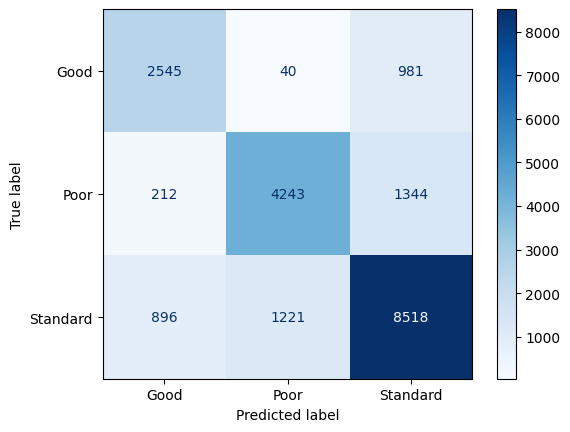

In [ ]:
ConfusionMatrixDisplay.from_estimator(cat_model,X_test,y_test,display_labels=le.classes_,cmap="Blues")
plt.show()

In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": cat_model.feature_importances_
})
importance = importance.sort_values("Importance",ascending=False)

importance.head(20)

,Feature,Importance
14,Credit_Mix,7.926130
8,Interest_Rate,7.369330
7,Num_Credit_Card,4.427223
12,Changed_Credit_Limit,3.915869
49,Credit_Health_Index,3.865888
0,Customer_ID,3.496277
11,Num_of_Delayed_Payment,2.912934
54,Delay_from_due_date_mean,2.643162
1,Month,2.635026
48,Month_cos,2.453702


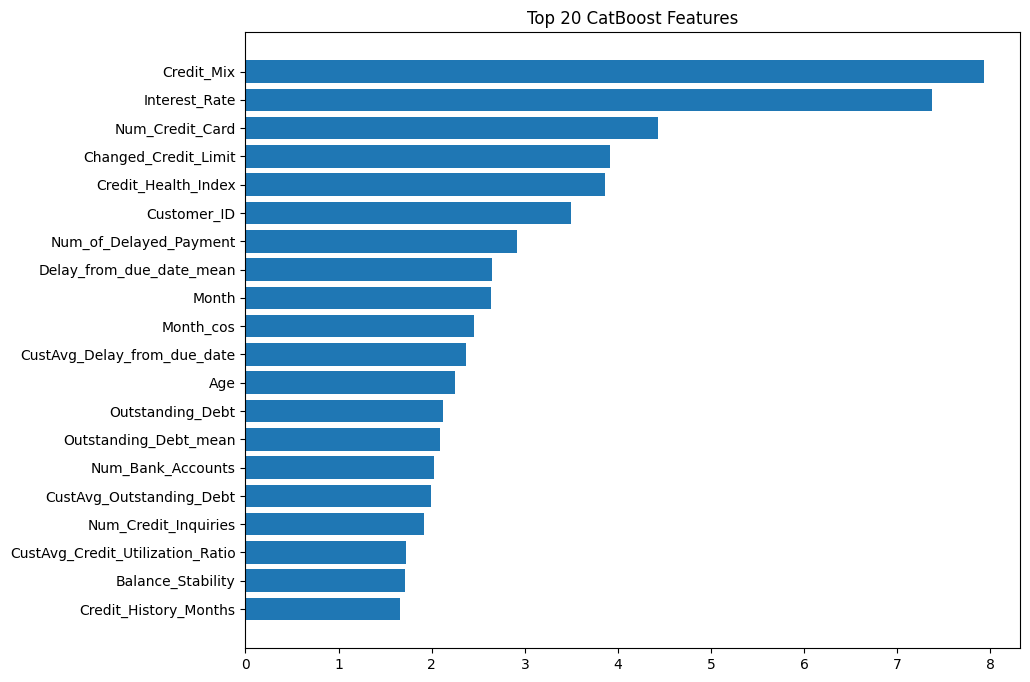

In [ ]:
top20 = importance.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top20["Feature"],
    top20["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 20 CatBoost Features")

plt.show()

In [ ]:
y_prob = cat_model.predict_proba(X_test)

In [ ]:
cat_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03,
    depth=10,
    l2_leaf_reg=5,
    random_strength=1,
    bagging_temperature=1,
    loss_function="MultiClass",
    eval_metric="Accuracy",
    random_seed=42,
    verbose=100
)

#Try XGboost Model

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=3,
    random_state=42,
    eval_metric="mlogloss"
)

xgb.fit(X_train, y_train)

pred = xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test,pred))
print(classification_report(y_test,pred))

Accuracy: 0.81995
              precision    recall  f1-score   support

           0       0.79      0.78      0.79      3566
           1       0.80      0.83      0.82      5799
           2       0.84      0.82      0.83     10635

    accuracy                           0.82     20000
   macro avg       0.81      0.81      0.81     20000
weighted avg       0.82      0.82      0.82     20000



In [ ]:
from sklearn.ensemble import ExtraTreesClassifier

et = ExtraTreesClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

et.fit(X_train,y_train)

pred=et.predict(X_test)

print(accuracy_score(y_test,pred))

0.8288


# Final Conclusion

• Initial Random Forest Accuracy: 81.60%

• After Feature Engineering:
83.05%

• Improvement:
+1.45%

• Best Model:
Random Forest

Reason:
Highest accuracy with balanced precision, recall and F1 score.

Important Features:

Outstanding Debt

Interest Rate

Credit Mix

Credit Health Index

Outstanding Debt Mean

In [ ]:
import joblib

joblib.dump(best_rf, "credit_score_rf.pkl")
joblib.dump(encoder, "ordinal_encoder.pkl")
joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']

In [ ]:
pred = best_rf.predict(X_test)
pred = le.inverse_transform(pred)